# 15. PMD ATAC

Part of the **[Fig. 2 chapter](fig2.md)** — see it for the panel-by-panel map. The first code cell sets `ENTEX_ROOT` and activates the no-overwrite guard (see the [Reproduction guide](../reproduce.md)). *Outputs shown are the author's original run.*


## 📥 Required input files

This notebook reads the following files (paths resolve from `ENTEX_ROOT`/`REF_ROOT`; the setup cell sets them). See the chapter's `inputs.md` for RAW-vs-derived tags.

- `f'{indir}L1color.tsv'`  ·  _metadata: color_
- `f'{indir}scATAC/celltypes.txt.gz'`  ·  _scATAC peaks_
- `f'{indir}scATAC/peak/peaklist.txt'`  ·  _scATAC peaks_
- `f'{indir}scATAC/cCREs.bed.gz'`  ·  _scATAC peaks_
- `f'{indir}scATAC/atac2majortype.tsv'`  ·  _scATAC peaks_
- `f'{pmddir}{ct}_10kb_hist.h5ad'`  ·  _PMD/methyl-compartment_
- `f'{tssdir}tss_{ct}_3state.txt'`  ·  _other_
- `f'{outdir}{ct}_peak_3state.txt'`  ·  _other_
- `f'{indir}clustering/tissue/L1/PBMC/5kCG100k3C_embed.h5ad'`  ·  _embedding h5ad_
- `f'{indir}clustering/merged/L1pre/merge_5kCG_echo_entex_immune.h5ad'`  ·  _other_
- `f'{indir}scATAC/PBMC/PBMC10k.h5ad'`  ·  _scATAC peaks_
- `f'{ENTEX_ROOT}/analysis/PMD_ATAC/peak/Th-Memory.slop25k.500bp.Th-Mem.CGN-Merge.tsv'`  ·  _PMD/methyl-compartment_
- `f'{ENTEX_ROOT}/analysis/PMD_ATAC/peak/Th-Memory_diff.slop25k.500bp.Th-Mem.CGN-Merge.tsv'`  ·  _PMD/methyl-compartment_
- `f'PMD_ATAC/peak/{group_name}-{peak_ct}_diff.slop25k.500b.{group_name}-{mc_ct}.CGN-Merge.tsv'`  ·  _PMD/methyl-compartment_
- `f'PMD_ATAC/peak/{group_name}-{peak_ct}_diff.split1.slop250kb.5kb.{group_name}-{mc_ct}.CGN-Merge.tsv'`  ·  _PMD/methyl-compartment_
- `'PMD_ATAC/peak/Hema-Tmem.pmd.slop25k.bed'`  ·  _PMD/methyl-compartment_
- `f'{ENTEX_ROOT}/analysis/PMD_ATAC/peak/Hema-Tmem.pmd.slop25k.500bp.Th-Mem.CGN-Merge.tsv'`  ·  _PMD/methyl-compartment_


In [ ]:
# === Reproduction setup — edit ENTEX_ROOT / REF_ROOT for your machine ===
import os, sys
ENTEX_ROOT = os.environ.get('ENTEX_ROOT', '/large_storage/zhoulab/zhoujt/project/ENTEx')
REF_ROOT   = os.environ.get('REF_ROOT',   '/large_storage/zhoulab/ref')
BOOK_ROOT  = os.environ.get('BOOK_ROOT',  f'{ENTEX_ROOT}/analysis/HumanCellEpigenomeAtlas')
sys.path.insert(0, BOOK_ROOT)
os.chdir(f'{ENTEX_ROOT}/analysis')   # original working directory
import repro_guard                    # no-overwrite guard (default: skip existing)

In [ ]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

import cooler
import anndata
import scanpy as sc
import scanpy.external as sce
from sklearn.preprocessing import normalize
from sklearn.decomposition import TruncatedSVD

from ALLCools.clustering import *
from ALLCools.plot import *

import snapatac2 as snap
import warnings
warnings.filterwarnings("ignore")

mpl.style.use('default')
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = 'Helvetica'


In [ ]:
indir = f'{ENTEX_ROOT}/'
pmddir = f'{indir}analysis/PMD/L1/'
tssdir = f'{indir}analysis/PMD_RNA/flank_bed/'
outdir = f'{indir}analysis/PMD_ATAC/all/'


In [ ]:
chrom_size_path = f'{REF_ROOT}/hg38/fasta/hg38.main.chrom.sizes'
chrom_sizes = cooler.read_chromsizes(chrom_size_path, all_names=True)
chrom_sizes = chrom_sizes.iloc[:22]


In [ ]:
L1_meta = pd.read_csv(f'{indir}L1color.tsv', sep='\t', header=0, index_col=0)
L1_meta = L1_meta.drop(['c7'], axis=0)
L1_annot = L1_meta['L1_abbr'].to_dict()
L1_color = L1_meta['color'].to_dict()
L1_color.update({L1_annot[k]: L1_color[k] for k in L1_annot if k in L1_color})  # also key by name


In [ ]:
import scipy.io as sio

peak_matrix = sio.mmread(f'{indir}scATAC/matrix.tsv.gz')


In [ ]:
atac_ct_list = pd.read_csv(f'{indir}scATAC/celltypes.txt.gz', index_col=0, header=None).index
selct = pd.read_csv(f'{indir}scATAC/peak/peaklist.txt', sep='.', index_col=0, header=None).index
selct = atac_ct_list[atac_ct_list.isin(selct)]
print(selct.shape[0])


In [ ]:
peak = pd.read_csv(f'{indir}scATAC/cCREs.bed.gz', sep='\t', names=['chrom','start','end'], 
                   header=None, index_col=None)


In [ ]:
peak_matrix = peak_matrix.tocsr()[:, atac_ct_list.isin(selct)]
selp = peak_matrix.getnnz(axis=1)>0
peak = peak.loc[selp]
peak_matrix = peak_matrix[selp]


In [ ]:
# peak.to_csv(f'{indir}scATAC/cCREs_selct.bed.gz', sep='\t', header=False, index=False)


In [ ]:
# split = 0
# ws = '2k'
# w = '50'
# peak_ct = 'cCREs_distal2k'
# region = pd.read_csv(f'{outdir}{peak_ct}.bed', sep='\t', header=None, index_col=None)
# selp = peak.reset_index(drop=True).reset_index().set_index(['chrom','start']).loc[region.set_index([0,1]).index, 'index'].values
# peak_matrix = peak_matrix[selp]


In [ ]:
atac2mt = pd.read_csv(f'{indir}scATAC/atac2majortype.tsv', sep='\t', header=None, index_col=None)
atac2mt = atac2mt.loc[~atac2mt[1].isna()]

In [ ]:
mt2atac = {xx:[] for xx in L1_meta['L1_abbr']}
for xx,yy in atac2mt.values:
    for y in yy.split(','):
        mt2atac[y].append(xx)
    

In [ ]:
selct = pd.Series(np.arange(len(selct)), index=selct)

In [ ]:
ctcre = []
for ct in L1_meta.index:
    ctname = L1_annot[ct]
    if len(mt2atac[ctname])>0:
        selp = peak_matrix[:, selct.loc[mt2atac[ctname]]].getnnz(axis=1)>0
        peak.loc[selp].to_csv(f'{outdir}{ct}_peak.bed', index=False, header=False, sep='\t')
        ctcre.append(ct)

ctcre = pd.Index(ctcre)
print(len(ctcre))


In [ ]:

def mapstate(ct):
    adata = anndata.read_h5ad(f'{pmddir}{ct}_10kb_hist.h5ad')
    adata.obs[['chrom', 'start', 'end']] = adata.obs.index.str.split('-').to_list()
    adata.obs[['chrom', 'start', 'end', 'kmeans3']].to_csv(f'{pmddir}{ct}_3state.bed', index=False, header=False, sep='\t')
    cmd = f'bedtools intersect -wa -wb -a {tssdir}tss.bed -b {pmddir}{ct}_3state.bed -f 0.5 | sort -k1,1 -k2,2n -u > {tssdir}tss_{ct}_3state.txt'
    os.system(cmd)
    tss_state = pd.read_csv(f'{tssdir}tss_{ct}_3state.txt', sep='\t', header=None, index_col=None)
    count = pd.concat([adata.obs['kmeans3'].value_counts(), 
                       tss_state[9].value_counts()], 
                      axis=1)
    count.columns = [f'{ct}-All', f'{ct}-TSS']
    if ct in ctcre:
        cmd = f'bedtools intersect -wa -wb -a {outdir}{ct}_peak.bed -b {pmddir}{ct}_3state.bed -f 0.5 | sort -k1,1 -k2,2n -u > {outdir}{ct}_peak_3state.txt'
        os.system(cmd)
        peak_state = pd.read_csv(f'{outdir}{ct}_peak_3state.txt', sep='\t', header=None, index_col=None)
        count[f'{ct}-cCRE'] = peak_state[6].value_counts()
    else:
        count[f'{ct}-cCRE'] = 0
    return count


In [ ]:
from concurrent.futures import ProcessPoolExecutor, as_completed

cpu = 20
with ProcessPoolExecutor(cpu) as executor:
    futures = {}
    for ct in ctcre:
        future = executor.submit(
            mapstate,
            ct=ct,
        )
        futures[future] = ct

    result = {}
    for future in as_completed(futures):
        ct = futures[future]
        result[ct] = future.result()
        print(f'{ct} finished')


In [ ]:
cluster_color = {i:xx for i,xx in zip([0,1,1,2], sns.color_palette('Set2', 4))}


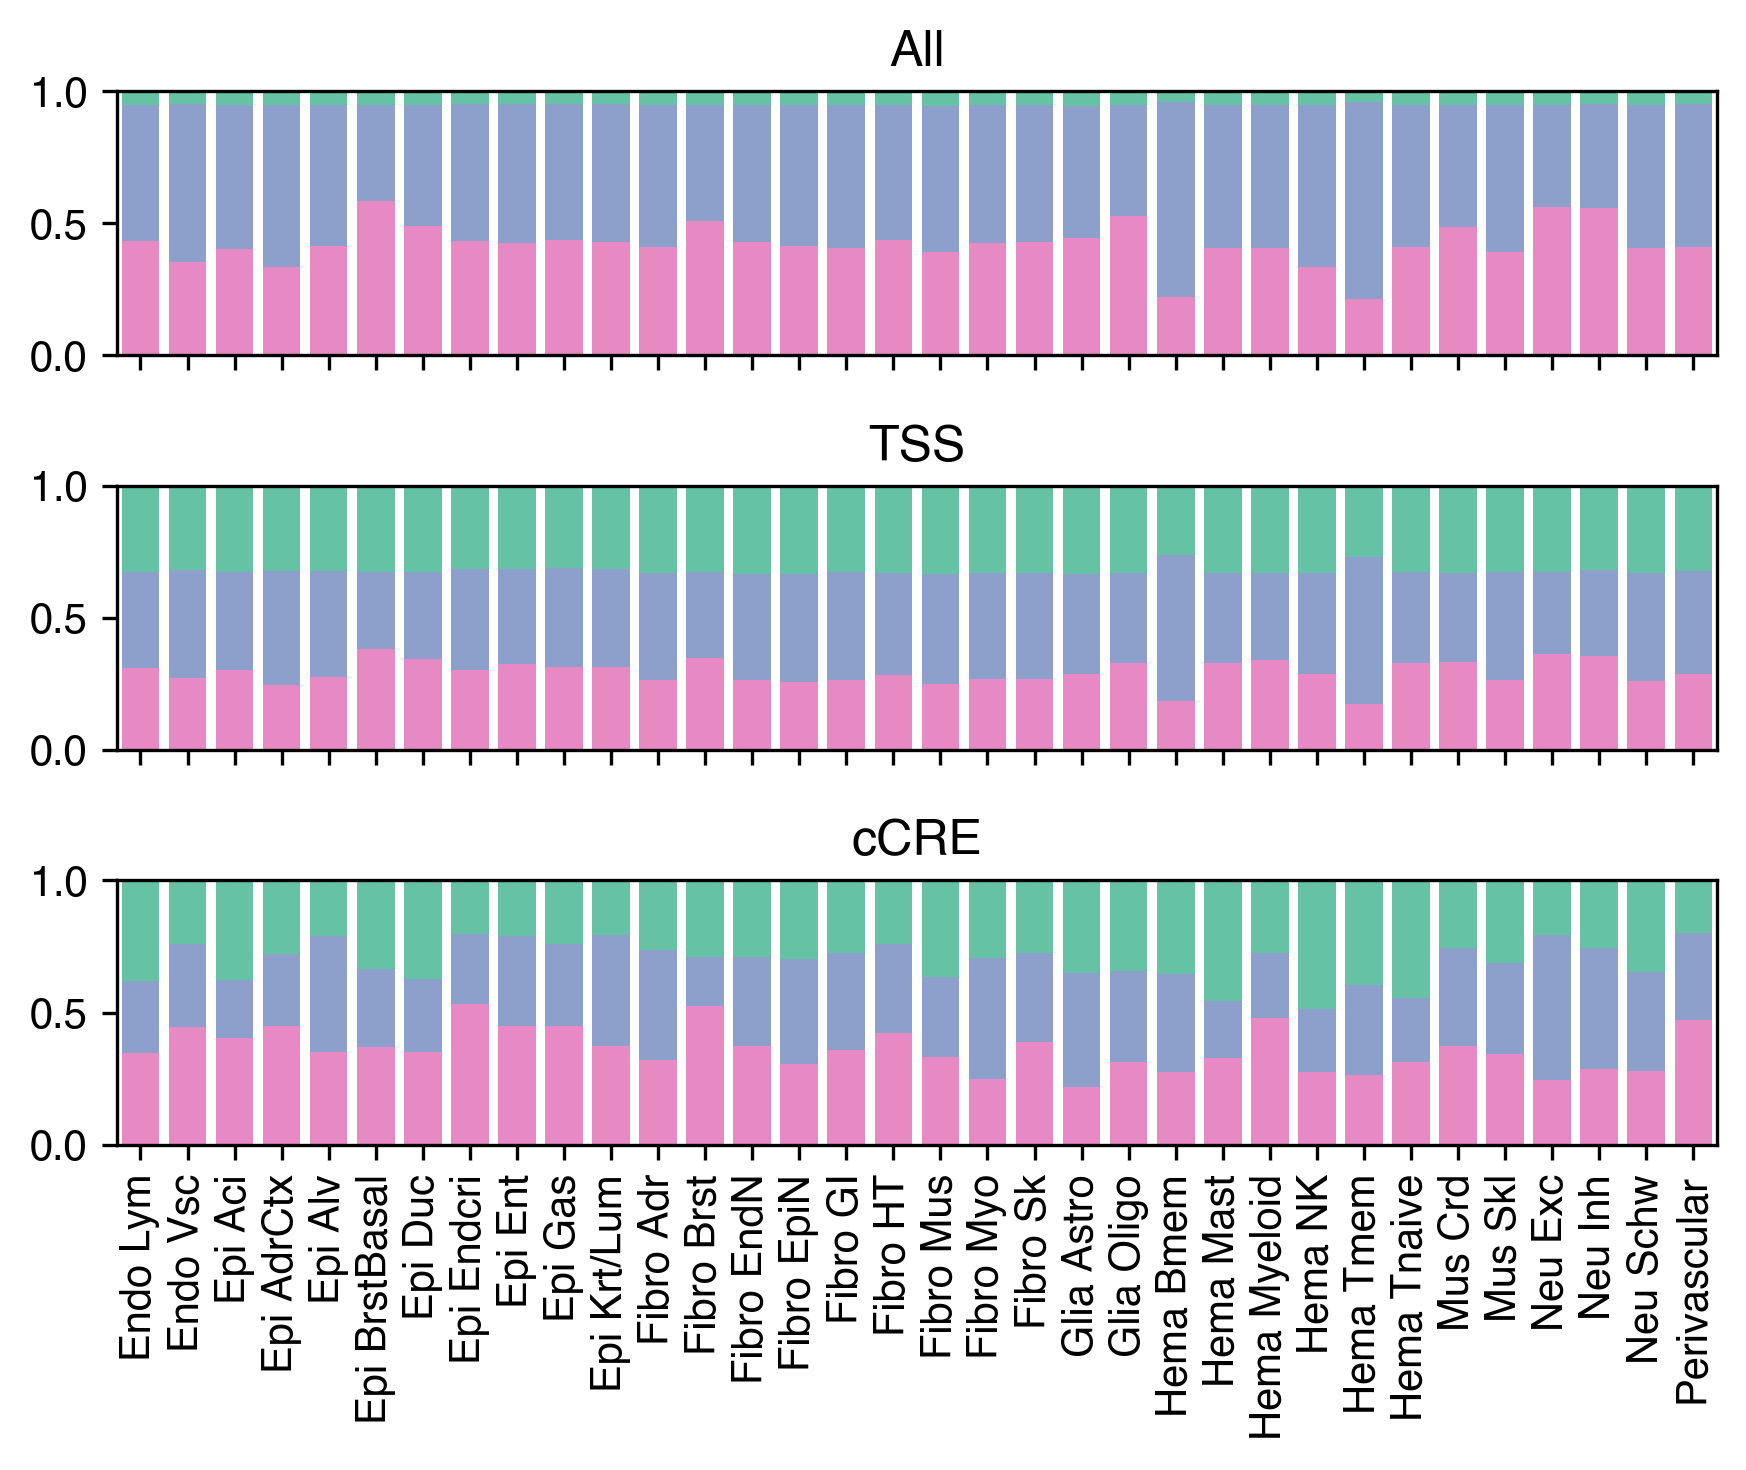

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(6,5), sharex='all', dpi=300)
for i, mode in enumerate(['All', 'TSS', 'cCRE']):
    ax = axes[i]
    data = pd.concat([result[ct][[f'{ct}-{mode}']] for ct in ctcre], axis=1).loc[np.arange(3)]
    data = data.iloc[::-1] / data.sum(axis=0)
    data.columns = data.columns.str.split('-').str[0].map(L1_annot)
    data.T.plot.bar(stacked=True, color=cluster_color, ax=ax, width=0.8)
    ax.get_legend().remove()
    ax.set_title(mode)
    ax.set_ylim([0,1])
    ax.set_xlim([-0.5, len(ctcre)-0.5])
    
fig.tight_layout()
fig.savefig(f'{outdir}ATAC_peak_3state_stackedbar.pdf', transparent=True)


In [ ]:
for i, mode in enumerate(['All', 'TSS', 'cCRE']):
    ax = axes[i]
    data = pd.concat([result[ct][[f'{ct}-{mode}']] for ct in ctcre], axis=1).loc[np.arange(4)]
    data = data.iloc[::-1] / data.sum(axis=0)
    data.columns = data.columns.str.split('-').str[0].map(L1_annot)
    print(data.mean(axis=1))
    

In [ ]:
def dump_embedding(adata, name, n_dim=2):
    # put manifold coordinates into adata.obs
    for i in range(n_dim):
        adata.obs[f'{name}_{i}'] = adata.obsm[f'X_{name}'][:, i]
    return adata


In [ ]:
indir = '/mnt/disks/jupyter/home/jzhou_salk_edu/sky_workdir/ENTEx/'


In [ ]:
adata = anndata.read_h5ad(f'{indir}clustering/tissue/L1/PBMC/5kCG100k3C_embed.h5ad')
adata

In [ ]:
adata_merge = anndata.read_h5ad(f'{indir}clustering/merged/L1pre/merge_5kCG_echo_entex_immune.h5ad')
adata_merge

In [ ]:
selc = adata.obs.index[adata.obs.index.isin(adata_merge.obs.index)]
adata_merge.obs['celltype'] = adata_merge.obs['celltype'].astype(str)
adata_merge.obs.loc[selc, 'celltype'] = adata.obs.loc[selc, 'leiden_cons'].values

In [ ]:
selc = [[6], [3,5,9,11], [0,4], [2,7,14], [1], [13]]
leg = ['Tc-Naive', 'Th-Naive', 'Th-Mem', 'Tc-Mem', 'B-Naive', 'B-Mem']
tmp = adata.obs.loc[adata.obs['leiden_cons'].str[1:].astype(int).isin(np.concatenate(selc))]
tmp['leiden_merge'] = ''
for xx,yy in zip(selc, leg):
    selcell = tmp['leiden_cons'].str[1:].astype(int).isin(xx)
    tmp.loc[selcell, 'leiden_merge'] = yy


In [ ]:
tmp['allcpath'] = '/gale/netapp/entex/ENTEx/allc_CGN/' + tmp.index + '.CGN-Both.allc.tsv.gz'
tmp[['allcpath', 'leiden_merge']].to_csv('PMD_ATAC/allclist_PBMC_celltype.csv', index=False, header=False)


In [ ]:
indir = f'{ENTEX_ROOT}/'

In [ ]:
adata_atac = snap.read(snap.datasets.pbmc10k_multiome(modality='ATAC'), backed=None)
adata_atac

In [ ]:
adata_atac.obs['cell_type'].value_counts()

In [ ]:
adata_atac.obs['domain'].value_counts()

In [ ]:
data = snap.pp.import_data(
    f'{indir}scATAC/frag/pbmc_granulocyte_sorted_10k_atac_fragments.tsv.gz',
    chrom_sizes=snap.genome.hg38,
    file=f'{indir}scATAC/h5ad/PBMC10k.h5ad',
    sorted_by_barcode=False,
    n_jobs=36,
)
# data = snap.read(f'{outdir}{sample}_atac.h5ad')
snap.metrics.tsse(data, snap.genome.hg38)
data.close()


In [ ]:
import os
cmd = f'cp {indir}scATAC/h5ad/PBMC10k.h5ad {indir}scATAC/PBMC/'
os.system(cmd)


In [ ]:
data = snap.read(f'{indir}scATAC/PBMC/PBMC10k.h5ad')


In [ ]:
selc = pd.Series(data.obs_names).isin(adata_atac.obs.index)
data.subset(selc)


In [ ]:
snap.pp.add_tile_matrix(data, bin_size=5000)


In [ ]:
data.obsm['X_umap'] = pd.DataFrame(adata_atac.obsm['X_umap'], index=adata_atac.obs.index).loc[data.obs_names].values
data.obsm['X_spectral'] = pd.DataFrame(adata_atac.obsm['X_spectral'], index=adata_atac.obs.index).loc[data.obs_names].values
data.obs['cell_type'] = adata_atac.obs.loc[data.obs_names, 'cell_type'].astype(str).values


In [ ]:
data.close()

In [ ]:
# import h5py
# from anndata._io.specs import read_elem

# with h5py.File(f'{indir}scATAC/PBMC/PBMC10k.h5ad') as f:
#     tmp = read_elem(f['obs'])

In [ ]:
adata_atac = anndata.read_h5ad(f'{indir}scATAC/PBMC/PBMC10k.h5ad')
adata_atac

In [ ]:
ds = 4
coord_base = 'umap'
dump_embedding(adata_atac, coord_base)


In [ ]:
import h5py
from anndata._io.specs import read_elem

with h5py.File(f'{indir}scATAC/PBMC/PBMC10k.h5ad') as f:
    meta_atac = read_elem(f['obs'])


In [ ]:
leg = {'Th': [['CD4 Naive'], ['CD4 TCM', 'CD4 TEM']], 
       'Tc': [['CD8 Naive'], ['CD8 TEM_1', 'CD8 TEM_2']], 
       'B': [['Naive B'], ['Memory B']]}


In [ ]:
# group_name = 'Th'
legmap = {xx:f'{g}-{yy}' for g in leg for yy,x in zip(['Naive', 'Mem'], leg[g]) for xx in x}
legmap

In [ ]:
selc = meta_atac.index[meta_atac['cell_type'].isin(legmap.keys())]
print(len(selc))


In [ ]:
data = snap.read(f'{indir}scATAC/PBMC/PBMC10k.h5ad')
adata_tmp = data.subset(obs_indices=selc, out='PMD_ATAC/PBMC10k_Lym.h5ad', inplace=False, backend=None)
data.close()


In [ ]:
label = pd.Series(adata_tmp.obs['cell_type']).map(legmap)
adata_tmp.obs['group'] = label.values
snap.tl.macs3(adata_tmp, groupby = 'group', n_jobs=32)
snap.ex.export_coverage(adata_tmp, groupby='group', out_dir='PMD_ATAC/bigwig/')
adata_tmp.close()


In [ ]:
# adata_tmp = snap.read('PMD_ATAC/PBMC10k_CD4.h5ad')

In [ ]:
# for ct in adata_tmp.uns['macs3']:
#     pd.DataFrame(adata_tmp.uns['macs3'][ct]).to_csv(f'PMD_ATAC/peak/{group_name}-{ct}.bed.gz', sep='\t', header=None)


In [ ]:
# peaks = snap.tl.merge_peaks(adata_tmp.uns['macs3'], snap.genome.hg38)
# peak_mat = snap.pp.make_peak_matrix(adata_tmp, use_rep=peaks['Peaks'])
# marker_peaks = snap.tl.marker_regions(peak_mat, groupby='group', pvalue=0.05)


In [ ]:
data = snap.read('PMD_ATAC/PBMC10k_Lym.h5ad')


In [ ]:
# count = pd.Series(data.obs['cell_type']).value_counts()

In [ ]:
# snap.tl.macs3(data, groupby='cell_type', n_jobs=32, selections=set(count.index[count>50]))


In [ ]:
peaks = snap.tl.merge_peaks(data.uns['macs3'], snap.genome.hg38)
peak_mat = snap.pp.make_peak_matrix(data, use_rep=peaks['Peaks'])
data.close()


In [ ]:
peaks = pd.DataFrame(peaks, columns=peaks.columns).set_index('Peaks')

In [ ]:
for xx in peaks.columns:
    tmp = peaks.index[peaks[xx]]
    tmp = pd.DataFrame(index=tmp.str.split(r'[:-]', expand=True)).reset_index()
    tmp.columns = ['chrom', 'start', 'end']
    tmp = tmp.sort_values(by=['chrom', 'start'])
    tmp.to_csv(f'PMD_ATAC/peak/{xx}.bed', sep='\t', index=False, header=False)
    

In [ ]:
tmp = peaks.index
tmp = pd.DataFrame(index=tmp.str.split(r'[:-]', expand=True)).reset_index()
tmp.columns = ['chrom', 'start', 'end']
tmp = tmp.sort_values(by=['chrom', 'start'])
tmp.to_csv(f'PMD_ATAC/peak/all.bed', sep='\t', index=False, header=False)


In [ ]:
peak_mat.var = peaks.astype(bool)
peak_mat.write_h5ad('PMD_ATAC/PBMC10k_Lym_peak.h5ad')


In [ ]:
def write_peak(regions, output_file):
    peak = []
    for xx in regions:
        chrom, pos = xx.split(':')
        start, end = pos.split('-')
        peak.append([chrom, int(start), int(end)])

    peak = pd.DataFrame(peak, columns=['chrom', 'start', 'end'])
    peak.sort_values(by=['chrom', 'start']).to_csv(output_file, sep='\t', index=False, header=False)
    return


In [ ]:
# for group_name in leg.keys():
#     selc_naive = pd.Series(data.obs['cell_type']).isin(leg[group_name][0])
#     selc_mem = pd.Series(data.obs['cell_type']).isin(leg[group_name][1])
#     peaks_selected = np.bitwise_or.reduce([peaks[xx] for xx in np.concatenate(leg[group_name])], axis=0)
#     print(peaks_selected.sum())
#     diff_peaks = snap.tl.diff_test(
#         peak_mat,
#         cell_group1=selc_naive,
#         cell_group2=selc_mem,
#         features=peaks_selected,
#     )
#     diff_peaks = pd.DataFrame(diff_peaks, columns=['feature name', 'log2(fold_change)', 'p-value', 'adjusted p-value']).set_index('feature name')
#     selp_naive = (diff_peaks['log2(fold_change)']>1) & (diff_peaks['adjusted p-value']<1e-3)
#     selp_mem = (diff_peaks['log2(fold_change)']<-1) & (diff_peaks['adjusted p-value']<1e-3)
#     print(selp_naive.sum(), selp_mem.sum())
#     write_peak(diff_peaks.loc[selp_naive].index, f'PMD_ATAC/peak/{group_name}-Naive_diff.bed')
#     write_peak(diff_peaks.loc[selp_mem].index, f'PMD_ATAC/peak/{group_name}-Mem_diff.bed')


In [ ]:
for g in leg.keys():
    legtmp = pd.Index([f'{g}-Naive', f'{g}-Mem'])
    selc_naive = pd.Series(data.obs['group'])==legtmp[0]
    selc_mem = pd.Series(data.obs['group'])==legtmp[1]
    peaks_selected = np.bitwise_or.reduce([peaks[xx] for xx in legtmp], axis=0)
    print(peaks_selected.sum())
    diff_peaks = snap.tl.diff_test(
        peak_mat,
        cell_group1=selc_naive,
        cell_group2=selc_mem,
        features=peaks_selected,
    )
    diff_peaks = pd.DataFrame(diff_peaks, columns=['feature name', 'log2(fold_change)', 'p-value', 'adjusted p-value']).set_index('feature name')
    diff_peaks.to_hdf(f'PMD_ATAC/DAR_{g}_stats.hdf', key='data')
    selp_naive = (diff_peaks['log2(fold_change)']>1) & (diff_peaks['adjusted p-value']<1e-3)
    selp_mem = (diff_peaks['log2(fold_change)']<-1) & (diff_peaks['adjusted p-value']<1e-3)
    print(selp_naive.sum(), selp_mem.sum())
    write_peak(diff_peaks.loc[selp_naive].index, f'PMD_ATAC/peak/{legtmp[0]}_diff.bed')
    write_peak(diff_peaks.loc[selp_mem].index, f'PMD_ATAC/peak/{legtmp[1]}_diff.bed')


In [ ]:
leg = pd.Index([f'{g}-{xx}' for g in leg for xx in ['Naive', 'Mem']])
ct_peak = []
for ct in leg:
    ct_peak.append(peak_mat.X[peak_mat.obs['group']==ct].sum(axis=0).A1)

ct_peak = pd.DataFrame(ct_peak, index=leg, columns=peak_mat.var.index)
ct_peak.to_hdf('PMD_ATAC/PBMC10k_Lym_bulk_peak.hdf', key='data')


In [ ]:
import cooler
chrom_size_path = '/large_experiments/zhoulab/ref/hg38/fasta/hg38.main.chrom.sizes'
chrom_sizes = cooler.read_chromsizes(chrom_size_path, all_names=True)
chrom_sizes = chrom_sizes.iloc[:22]


In [ ]:
def expand_bed(input_file, window_size, window, split, min_split_size):

    dist = window_size * window
    dist_str = num2str(dist)
    ws_str = num2str(window_size)
    bed = pd.read_csv(input_file, sep='\t', header=None, index_col=None, usecols=[0,1,2], names=['chrom', 'start', 'end'])
    bed = bed.loc[bed['chrom'].isin(chrom_sizes.index)]

    if split==0:
        mid = ((bed['start'] + bed['end']) // 2).astype(int)
        bed['start'], bed['end'] = mid.copy(), mid.copy()
    bed['start'] = bed['start'] - dist
    bed['end'] = bed['end'] + dist
    bed = bed.loc[(bed['start']>0) & (bed['end']<bed['chrom'].map(chrom_sizes))]
    
    bed_new = []
    for idx,xx,yy,zz in bed.reset_index().values:
        if split>0:
            split_size = (zz-yy-2*dist) / split
            if split_size<min_split_size:
                continue
        for i in range(window):
            bed_new.append([xx, yy+window_size*i, yy+window_size*(i+1), f'{idx}_{i}'])
        # if (yy+dist)<(zz-dist):
        #     bed_new.append([xx, yy+dist, zz-dist])
        if split>0:
            for i in range(split):
                bed_new.append([xx, yy+dist+split_size*i, yy+dist+split_size*(i+1), f'{idx}_{window+i}'])
        for i in range(window):
            bed_new.append([xx, zz-dist+window_size*i, zz-dist+window_size*(i+1), f'{idx}_{window+split+i}'])

    print(len(bed_new))
    bed_new = pd.DataFrame(bed_new)
    bed_new[[1,2]] = np.around(bed_new[[1,2]], decimals=0).astype(int)
    bed_new.to_csv(input_file.replace('.bed',f'.split{split}.slop{dist_str}b.{ws_str}b.bed'), sep='\t', header=False, index=False)
    return dist_str, ws_str


In [ ]:
import os
import time
def num2str(num):
    if num>=1e6:
        num_str = f'{int(num//1e6)}m'
    elif num>=1e3:
        num_str = f'{int(num//1e3)}k'
    else:
        num_str = f'{num}'
    return num_str
        
def generate_flankmap(peak_group, mc_group, window_size=500, window=50, split=0, min_split_size=1):
    dist_str, ws_str = expand_bed(f'{peak_group}.bed', window_size=window_size, window=window, split=split, min_split_size=min_split_size)
    time.sleep(3)
    cmd = f'bigWigAverageOverBed {mc_group}.CGN-Merge.frac.bw {peak_group}.split{split}.slop{dist_str}b.{ws_str}b.bed {peak_group}.split{split}.slop{dist_str}b.{ws_str}b.{mc_group.split("/")[-1]}.CGN-Merge.tsv'
    os.system(cmd)
    return


In [ ]:
peak_list = ['PMD_ATAC/peak/all']
bw_list = [f'PMD_ATAC/bigwig/{xx}' for xx in leg]
print(peak_list, bw_list)


In [ ]:
from concurrent.futures import ProcessPoolExecutor, as_completed

cpu = 32
ws = 10000
w = 50

with ProcessPoolExecutor(cpu) as executor:
    futures = {}
    for peak_ct in peak_list:
        for mc_ct in bw_list:
            future = executor.submit(generate_flankmap, 
                peak_ct, mc_ct,
                window_size=ws, window=w, split=1, min_split_size=1
            )
            futures[future] = f'{peak_ct}-{mc_ct}'
    result = {}
    for future in as_completed(futures):
        ct = futures[future]
        result[ct] = future.result()
        print(f'{ct} finished')


In [ ]:
ws = 100
w = 50


In [ ]:
data

In [ ]:
ws = 10000
w = 50


In [ ]:
for split, peak_ct in zip([1], peak_list):

    region = pd.read_csv(f'{peak_ct}.bed', sep='\t', header=None, index_col=None, names=['chrom', 'start', 'end'])
    region.index = region['chrom'].astype(str) + '-' + region['start'].astype(str)
    # selr = pd.read_csv(f'{peak_ct}.split{split}.slop25kb.500b.bed', index_col=3, header=None, sep='\t')
    # selr = selr.index.str.split('_').str[0].astype(int).unique()
    # region = region.iloc[selr]
    # selr = (region[5]=='-').values
    for xx in bw_list:
        mc_ct = xx.split('/')[-1]
        data = pd.read_csv(f'{peak_ct}.split{split}.slop{num2str(ws*w)}b.{num2str(ws)}b.{mc_ct}.CGN-Merge.tsv', sep='\t', header=None, index_col=0)
        selr = data.index.str.split('_').str[0].astype(int).unique()
        region_tmp = region.iloc[selr]
        ratio = data[5].values.reshape((-1, 100+split))
        cov = data[2].values.reshape((-1, 100+split))
        ratio[cov==0] = np.nan
        # selr = (region_tmp[5]=='-')
        # ratio[selr] = ratio[selr, ::-1]
        ratio = pd.DataFrame(ratio, index=region_tmp.index)
        ratio.to_hdf(f'{peak_ct}.split{split}.slop{num2str(ws*w)}b.{num2str(ws)}b.{mc_ct}.CGN-Merge.hdf', key='data')
        print(peak_ct, mc_ct)
        

In [ ]:
# group_name, peak_ct, mc_ct = 'Tc', 'Memory', 'Naive'
# generate_flankmap(peak_group=f'PMD_ATAC/peak/{group_name}-{peak_ct}_diff',
#                   mc_group=f'PMD_ATAC/bigwig/{group_name}-{mc_ct}',
#                   window_size=500, window=50, split=0, min_split_size=1
#                  )


In [ ]:
# group_name, peak_ct, mc_ct = 'Tc', 'Memory', 'Naive'
# generate_flankmap(peak_group=f'PMD_ATAC/peak/{group_name}-{peak_ct}_diff',
#                   mc_group=f'PMD_ATAC/bigwig/{group_name}-{mc_ct}',
#                   window_size=5000, window=50, split=1, min_split_size=1
#                  )


In [ ]:
# from concurrent.futures import ProcessPoolExecutor, as_completed

# cpu = 32
# with ProcessPoolExecutor(cpu) as executor:
#     futures = {}
#     for g in leg.keys():
#         for peak_ct in ['Naive', 'Mem']:
#             for mc_ct in ['Naive', 'Mem']:
#                 future = executor.submit(
#                     generate_flankmap,
#                     peak_group=f'PMD_ATAC/peak/{group_name}-{peak_ct}_diff',
#                     mc_group=f'PMD_ATAC/bigwig/{g}-{mc_ct}',
#                     window_size=5000, window=50, split=1, min_split_size=1
#                 )
#                 futures[future] = f'{group_name}-{peak_ct}-{mc_ct}'
#     result = {}
#     for future in as_completed(futures):
#         ct = futures[future]
#         result[ct] = future.result()
#         print(f'{ct} finished')
        

In [ ]:
!cat Th-Memory.bed.gz | cut -f2-4 | awk '{printf("%s\t%d\t%d\n", $1, ($2+$3)/2, ($2+$3)/2)}' | bedtools slop -b 25000 -i - -g /large_storage/zhoulab/ref/hg38/fasta/hg38.main.chrom.sizes | awk '($3-$2)==50000' > Th-Memory.slop25k.bed

cut -f1-3 Hema-Tmem.pmd.tsv | awk '{printf("%s\t%d\t%d\n", $1, ($2+$3)/2, ($2+$3)/2)}' | bedtools slop -b 25000 -i - -g /large_storage/zhoulab/ref/hg38/fasta/hg38.main.chrom.sizes | awk '($3-$2)==50000' > Hema-Tmem.pmd.slop25k.bed



In [ ]:
data = pd.read_csv(f'{ENTEX_ROOT}/analysis/PMD_ATAC/peak/Th-Memory.slop25k.500bp.Th-Mem.CGN-Merge.tsv', sep='\t', header=None, index_col=0)
data


In [ ]:
data = pd.read_csv(f'{ENTEX_ROOT}/analysis/PMD_ATAC/peak/Th-Memory_diff.slop25k.500bp.Th-Mem.CGN-Merge.tsv', sep='\t', header=None, index_col=0)
ratio = data[5].values.reshape((-1, 100))
cov = data[2].values.reshape((-1, 100))
ratio[cov==0] = 1.0


In [ ]:
idx = np.argsort(np.mean(ratio, axis=1))


In [ ]:
bed = pd.read_csv('PMD_ATAC/peak/Hema-Tmem.pmd.slop25k.bed', sep='\t', header=None, index_col=None, names=['chrom', 'start', 'end'])
bed = bed.loc[~bed['chrom'].isin(['chrX', 'chrY', 'chrM'])]
bed_new = []
for xx,yy,zz in bed.values:
    for tmp in np.arange(int(yy), int(zz), 500):
        bed_new.append([xx, tmp, tmp+500])
        
print(len(bed_new))


In [ ]:
bed_new = pd.DataFrame(bed_new).reset_index()
bed_new[[0,1,2,'index']].to_csv('PMD_ATAC/peak/Hema-Tmem.pmd.slop25k.500bp.bed', sep='\t', header=False, index=False)


In [ ]:
data = pd.read_csv(f'{ENTEX_ROOT}/analysis/PMD_ATAC/peak/Hema-Tmem.pmd.slop25k.500bp.Th-Mem.CGN-Merge.tsv', sep='\t', header=None, index_col=0)
data


In [ ]:
ratio = data[5].values.reshape((-1, 100))
cov = data[2].values.reshape((-1, 100))
ratio[cov==0] = 1.0

In [ ]:
idx = np.argsort(np.mean(ratio[:, 49:51], axis=1))
